In [90]:
!pip install yfinance

In [91]:
import yfinance as yf


ticker = yf.Ticker("AAPL")

print("=== CALENDAR ===")

try:
  print(ticker.calendar)
except Exception as e:
  print("calendar failed:", e)

print("=== EARNINGS ESTIMATE ===")
try:
  print(ticker.earnings_estimate)
except Exception as e:
  print("earnings_estimate failed:", e)

print("=== EARNINGS HISTORY ===")
try:
  print(ticker.earnings_history)
except Exception as e:
  print("earnings_history failed:", e)



=== CALENDAR ===
{'Dividend Date': datetime.date(2026, 8, 13), 'Ex-Dividend Date': datetime.date(2026, 8, 10), 'Earnings Date': [datetime.date(2026, 10, 29)], 'Earnings High': 2.07, 'Earnings Low': 1.93, 'Earnings Average': 1.98013, 'Revenue High': 117219700000, 'Revenue Low': 112137000000, 'Revenue Average': 113550860190}
=== EARNINGS ESTIMATE ===
            avg   low   high  yearAgoEps  numberOfAnalysts  growth
period                                                            
0q      1.97656  1.93   2.07     1.85000                28  0.0684
+1q     2.91256  2.51   3.42     2.84000                23  0.0255
0y      8.80268  8.28   8.94     7.46000                38  0.1800
+1y     9.53474  8.24  10.67     8.80268                40  0.0832
=== EARNINGS HISTORY ===
            epsActual  epsEstimate  epsDifference  surprisePercent
quarter                                                           
2025-09-30       1.85      1.76993           0.08           0.0452
2025-12-31       2.84

In [92]:
import yfinance as yf

t = yf.Ticker("AAPL")
result = t.get_earnings_history()

print("Type of result:", type(result))
print("---")
print(result)

Type of result: <class 'pandas.core.frame.DataFrame'>
---
            epsActual  epsEstimate  epsDifference  surprisePercent
quarter                                                           
2025-09-30       1.85      1.76993           0.08           0.0452
2025-12-31       2.84      2.67080           0.17           0.0634
2026-03-31       2.01      1.94275           0.07           0.0346
2026-06-30       2.02      1.89243           0.13           0.0674


In [93]:
import yfinance as yf
import pandas as pd
import time

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "JPM",
           "V", "WMT", "PG", "HD", "KO", "PEP", "DIS", "NKE"]

all_earnings = []

for symbol in tickers:
    try:
        t = yf.Ticker(symbol)
        hist = t.get_earnings_history()

        if hist is None or len(hist) == 0:
            print(f"{symbol}: no earnings data, skipping")
            continue

        hist = hist.copy()
        hist["ticker"] = symbol
        all_earnings.append(hist)
        print(f"{symbol}: got {len(hist)} quarters")

    except Exception as e:
        print(f"{symbol}: failed ({e}), skipping")

    time.sleep(0.5)

earnings = pd.concat(all_earnings)
print("Total earnings events collected:", len(earnings))
earnings.head(10)

AAPL: got 4 quarters
MSFT: got 4 quarters
GOOGL: got 4 quarters
AMZN: got 4 quarters
META: got 4 quarters
NVDA: got 4 quarters
JPM: got 4 quarters
V: got 4 quarters
WMT: got 4 quarters
PG: got 4 quarters
HD: got 4 quarters
KO: got 4 quarters
PEP: got 4 quarters
DIS: got 4 quarters
NKE: got 4 quarters
Total earnings events collected: 60


,epsActual,epsEstimate,epsDifference,surprisePercent,ticker
quarter,,,,,
2025-09-30,1.85,1.76993,0.08,0.0452,AAPL
2025-12-31,2.84,2.67080,0.17,0.0634,AAPL
2026-03-31,2.01,1.94275,0.07,0.0346,AAPL
2026-06-30,2.02,1.89243,0.13,0.0674,AAPL
2025-09-30,4.13,3.66355,0.47,0.1273,MSFT
2025-12-31,4.14,3.91702,0.22,0.0569,MSFT
2026-03-31,4.27,4.07062,0.20,0.0490,MSFT
2026-06-30,4.74,4.23939,0.50,0.1181,MSFT
2025-09-30,2.87,2.26199,0.61,0.2688,GOOGL


In [94]:
import yfinance as yf
import pandas as pd
import time

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "JPM", "V", "WMT", "PG", "HD", "KO", "PEP", "DIS", "NKE"]

all_events = []

for symbol in tickers:
  try:
    t = yf.Ticker(symbol)
    df = t.get_earnings_dates(limit=24)

    if df is None or len(df) == 0:
      print(f"{symbol}: no data, skipping")
      continue

    df = df.copy()
    df["ticker"] = symbol
    all_events.append(df)
    print(f"{symbol}: got {len(df)} rows")

  except Exception as e:
    print(f"{symbol}: failed, skipping")

  time.sleep(1)


events = pd.concat(all_events)

events = events.dropna(subset=["Surprise(%)"])

print("--- Summary --- ")
print("Stocks that succeeded:", events["ticker"].nunique())
print("Total Past Earnings Events", len(events))
events.head(10)




AAPL: got 25 rows
MSFT: got 25 rows
GOOGL: got 25 rows
AMZN: got 25 rows
META: got 25 rows
NVDA: got 25 rows
JPM: got 25 rows
V: got 25 rows
WMT: got 25 rows
PG: got 25 rows
HD: got 25 rows
KO: got 25 rows
PEP: got 25 rows
DIS: got 25 rows
NKE: got 25 rows
--- Summary --- 
Stocks that succeeded: 15
Total Past Earnings Events 360


,EPS Estimate,Reported EPS,Surprise(%),ticker
Earnings Date,,,,
2026-07-30 16:00:00-04:00,1.89,2.02,6.74,AAPL
2026-04-30 16:00:00-04:00,1.94,2.01,3.46,AAPL
2026-01-29 16:00:00-05:00,2.67,2.84,6.25,AAPL
2025-10-30 16:00:00-04:00,1.77,1.85,4.52,AAPL
2025-07-31 16:00:00-04:00,1.43,1.57,9.48,AAPL
2025-05-01 16:00:00-04:00,1.62,1.65,1.69,AAPL
2025-01-30 16:00:00-05:00,2.35,2.40,2.26,AAPL
2024-10-31 16:00:00-04:00,0.95,0.97,2.48,AAPL
2024-08-01 16:00:00-04:00,1.34,1.40,4.36,AAPL


In [95]:
import yfinance as yf
import pandas as pd

tickers = ["AAPL", "MSFT", "GOOGL","AMZN", "META", "NVDA", "JPM", "V", "WMT", "PG", "HD", "KO", "PEP", "DIS", "NKE"]

prices = yf.download(tickers, start="2019-01-01", end="2026-07-01", auto_adjust=True, progress=False)["Close"]

print("Shape (rows, ticker):", prices.shape)
print("Date range:", prices.index.min().date(), "to", prices.index.max().date())
print("Missing values per ticker:")
print(prices.isna().sum())
prices.tail




Shape (rows, ticker): (1883, 15)
Date range: 2019-01-02 to 2026-06-30
Missing values per ticker:
Ticker
AAPL     0
AMZN     0
DIS      0
GOOGL    0
HD       0
JPM      0
KO       0
META     0
MSFT     0
NKE      0
NVDA     0
PEP      0
PG       0
V        0
WMT      0
dtype: int64


<bound method NDFrame.tail of Ticker            AAPL        AMZN         DIS       GOOGL          HD  \
Date                                                                     
2019-01-02   37.436916   76.956497  104.377678   52.270504  143.130188   
2019-01-03   33.707924   75.014000  101.848938   50.822838  139.975555   
2019-01-04   35.146893   78.769501  104.990700   53.429729  144.134720   
2019-01-07   35.068653   81.475502  105.900665   53.323170  146.973907   
2019-01-08   35.737179   82.829002  106.724434   53.791523  147.679565   
...                ...         ...         ...         ...         ...   
2026-06-24  292.827423  234.270004  100.351067  345.290009  342.859985   
2026-06-25  274.912903  227.009995   97.304413  343.709991  345.000000   
2026-06-26  283.535461  232.690002   98.038780  337.390015  348.859985   
2026-06-29  281.497223  240.139999   97.879997  353.649994  350.809998   
2026-06-30  289.110657  238.339996   96.250000  357.369995  352.679993   

Ticker             JPM         KO        META        MSFT        NKE  \
Date                                                                   
2019-01-02   80.473984  37.341599  134.498871   94.193161  66.558624   
2019-01-03   79.330322  37.110855  130.593170   90.727959  65.381287   
2019-01-04   82.254829  37.850834  136.749130   94.947655  67.088844   
2019-01-07   82.312035  37.357517  136.848251   95.068741  68.050468   
2019-01-08   82.156807  37.779236  141.289246   95.758072  68.958191   
...                ...        ...         ...         ...        ...   
2026-06-24  331.954590  80.599998  557.669983  365.459991  41.820000   
2026-06-25  333.617065  80.419998  542.869995  352.829987  40.900002   
2026-06-26  327.574280  82.629997  550.250000  372.970001  40.750000   
2026-06-29  327.912781  82.650002  562.599976  368.570007  41.480000   
2026-06-30  325.862000  81.269997  563.289978  373.019989  41.049999   

Ticker            NVDA         PEP          PG           V         WMT  
Date                                                                    
2019-01-02    3.373052   86.693657   74.789940  125.834320   27.913778  
2019-01-03    3.169263   85.884491   74.265572  121.299675   27.770227  
2019-01-04    3.372309   87.645668   75.781357  126.525459   27.943686  
2019-01-07    3.550843   86.891998   75.478203  128.806946   28.272642  
2019-01-08    3.462442   87.724991   75.756760  129.507477   28.470016  
...                ...         ...         ...         ...         ...  
2026-06-24  199.000000  142.270004  150.913422  331.613953  119.000000  
2026-06-25  195.740005  139.520004  147.399658  329.907104  115.779999  
2026-06-26  192.529999  141.389999  147.915817  335.606537  115.690002  
2026-06-29  194.970001  138.679993  147.350021  341.016479  114.599998  
2026-06-30  200.089996  135.399994  145.553436  342.453796  113.260002  

[1883 rows x 15 columns]>

In [96]:
import pandas as pd

prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()

drift_days = 10

results = []

for _, row in events.iterrows():
  symbol = row["ticker"]
  surprise = row["Surprise(%)"]
  ann_date = pd.to_datetime(row.name).tz_localize(None).normalize()

  if symbol not in prices.columns:
    continue

  stock_prices = prices[symbol].dropna()
  future = stock_prices[stock_prices.index >= ann_date]

  if len(future) < drift_days + 2:
    continue

  reaction_day_price = future.iloc[1]
  drift_start_price = future.iloc[1]
  drift_end_price = future.iloc[1 + drift_days]

  drift_return = (drift_end_price / drift_start_price) - 1

  results.append({
  "ticker": symbol,
  "ann_date": ann_date,
  "surprise": surprise,
  "beat": surprise > 0,
  "drift_return": drift_return
  })

drift = pd.DataFrame(results)
print("Events Successfully Matched:", len(drift))
print("Beats vs. Misses:")
print(drift["beat"].value_counts())
drift.head(10)




Events Successfully Matched: 348
Beats vs. Misses:
beat
True     313
False     35
Name: count, dtype: int64


,ticker,ann_date,surprise,beat,drift_return
0,AAPL,2026-04-30,3.46,True,0.072702
1,AAPL,2026-01-29,6.25,True,-0.013337
2,AAPL,2025-10-30,4.52,True,0.008522
3,AAPL,2025-07-31,9.48,True,0.145631
4,AAPL,2025-05-01,1.69,True,0.030129
5,AAPL,2025-01-30,2.26,True,0.037580
6,AAPL,2024-10-31,2.48,True,0.010487
7,AAPL,2024-08-01,4.36,True,0.029344
8,AAPL,2024-05-02,1.46,True,0.036795
9,AAPL,2024-02-01,3.66,True,-0.017796


In [97]:
import pandas as pd

summary = drift.groupby("beat")["drift_return"].agg(["mean", "median","count", "std"])
print("=== Average 10-day drift after earnings ===")
print(summary)

print("--- In Plain Terms")
beat_mean = drift[drift["beat"]]["drift_return"].mean()
miss_mean = drift[~drift["beat"]]["drift_return"].mean()
print(f"After a BEAT: average {beat_mean*100:.2f}% over next 10 days")
print(f"After a MISS: average{miss_mean*100:.2f}% over next 10 days")
print(f"Difference: {(beat_mean - miss_mean)*100:.2f} percentage points")



=== Average 10-day drift after earnings ===
           mean    median  count       std
beat                                      
False -0.002916 -0.002518     35  0.076214
True   0.007822  0.007890    313  0.048270
--- In Plain Terms
After a BEAT: average 0.78% over next 10 days
After a MISS: average-0.29% over next 10 days
Difference: 1.07 percentage points


In [98]:
from scipy import stats

beats = drift[drift["beat"]]["drift_return"]
misses = drift[~drift["beat"]]["drift_return"]

t_stat, p_value = stats.ttest_ind(beats, misses, equal_var=False)

print(f"Beat mean: {beats.mean()*100:.2f}%")
print(f"Miss mean: {misses.mean()*100:.2f}%")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

print()
if p_value < 0.05:
  print("The difference is statistically different at the 5% level.")
else:
  print("The difference is NOT statistically different at the 5% level.")






Beat mean: 0.78%
Miss mean: -0.29%
t-statistic: 0.815
p-value: 0.4200

The difference is NOT statistically different at the 5% level.


In [99]:
from scipy import stats

beats = drift[drift["beat"]]["drift_return"]
misses = drift[~drift["beat"]]["drift_return"]

t_stat, p_value = stats.ttest_ind(beats, misses, equal_var=False)

print(f"Beat mean:  {beats.mean()*100:.2f}%  (n={len(beats)})")
print(f"Miss mean:  {misses.mean()*100:.2f}%  (n={len(misses)})")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

Beat mean:  0.78%  (n=313)
Miss mean:  -0.29%  (n=35)
t-statistic: 0.815
p-value:     0.4200


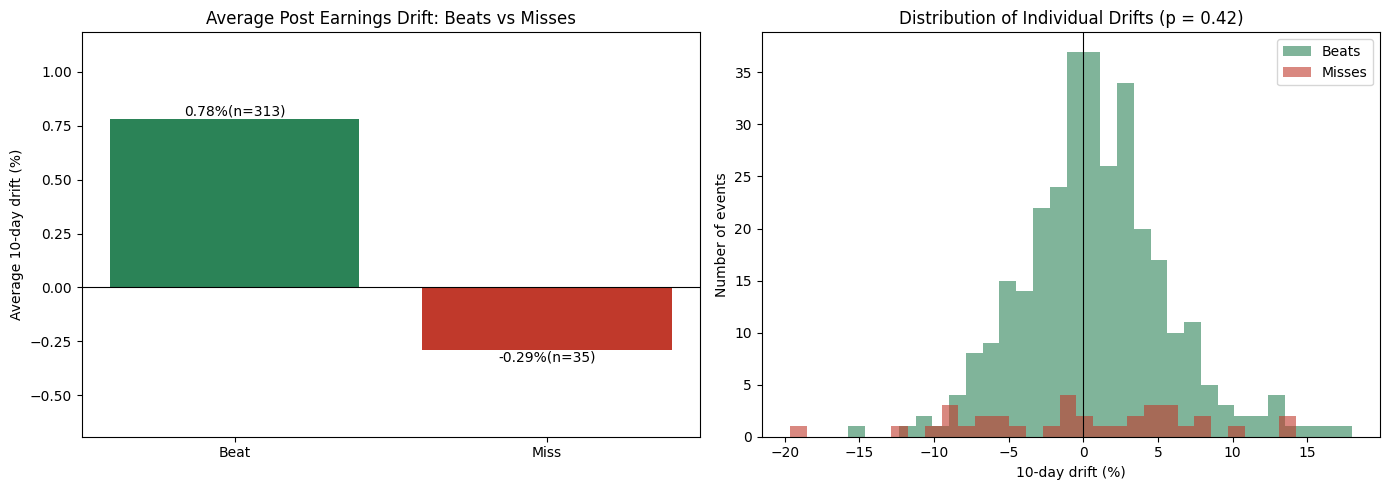

In [100]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

beat_mean  = drift[drift["beat"]]["drift_return"].mean() * 100
miss_mean = drift[~drift["beat"]]["drift_return"].mean() * 100

beat_n = drift["beat"].sum()
miss_n = (~drift["beat"]).sum()

bars = ax1.bar(["Beat", "Miss"], [beat_mean, miss_mean],
              color=["#2b8357", "#C0392b"])
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Average 10-day drift (%)")
ax1.set_title("Average Post Earnings Drift: Beats vs Misses")
ax1.set_ylim(miss_mean - 0.4, beat_mean + 0.4)


ax1.text(0, beat_mean, f"{beat_mean:.2f}%(n={beat_n})",
         ha="center", va="bottom")
ax1.text(1, miss_mean, f"{miss_mean:.2f}%(n={miss_n})",
         ha="center", va="top")

ax2.hist(drift[drift["beat"]]["drift_return"] * 100, bins=30,
        alpha=0.6, label="Beats", color="#2b8357")
ax2.hist(drift[~drift["beat"]]["drift_return"] * 100, bins=30,
         alpha=0.6, label="Misses", color="#c0392b")

ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("10-day drift (%)")
ax2.set_ylabel("Number of events")
ax2.set_title("Distribution of Individual Drifts (p = 0.42)")
ax2.legend()

plt.tight_layout()
plt.savefig("earnings_drift.png", dpi=150, bbox_inches="tight")
plt.show()

drift.to_csv("drift_data.csv", index=False)





